In [7]:
import numpy as np
from scipy.sparse.linalg import eigsh, LinearOperator
import os

os.makedirs('figureAKLT', exist_ok=True)

def spin_operators(S):
    d = int(2*S + 1)
    Sz = np.diag([S - m for m in range(d)])
    Sp = np.zeros((d, d))
    for m in range(d-1):
        s_val = S - m
        Sp[m, m+1] = np.sqrt(S*(S+1) - s_val*(s_val-1))
    Sm = Sp.T
    return Sz, Sp, Sm

class MPS:
    def __init__(self, L, d, D_max):
        self.L = L
        self.d = d
        self.D_max = D_max
        D_list = [1] + [min(D_max, d**min(i, L-i)) for i in range(1, L)] + [1]
        self.tensors = [np.random.randn(D_list[i], d, D_list[i+1]) + 
                       1j*np.random.randn(D_list[i], d, D_list[i+1]) for i in range(L)]
        
    def right_canonicalize(self):
        C = np.ones((1, 1), dtype=complex)
        for i in range(self.L-1, 0, -1):
            M = self.tensors[i]
            Dl, d, Dr = M.shape
            M_tilde = np.einsum('ijk,kl->ijl', M, C).reshape(Dl, d*Dr)
            Q, R = np.linalg.qr(M_tilde.T)
            self.tensors[i] = Q.T.reshape(Q.shape[1], d, Dr)
            C = R.T
        self.tensors[0] = np.einsum('ijk,kl->ijl', self.tensors[0], C)
        
    def left_canonicalize_site(self, i):
        M = self.tensors[i]
        Dl, d, Dr = M.shape
        Q, R = np.linalg.qr(M.reshape(Dl*d, Dr))
        self.tensors[i] = Q.reshape(Dl, d, Q.shape[1])
        return R

def build_heisenberg_mpo(L, Jx=1.0, Jy=1.0, Jz=1.0, h=0.0, S=0.5):
    Sz, Sp, Sm = spin_operators(S)
    d = int(2*S + 1)
    D_W = 5
    
    W = np.zeros((D_W, D_W, d, d), dtype=complex)
    W[0, 0] = np.eye(d)
    W[4, 4] = np.eye(d)
    W[4, 0] = h * Sz
    W[4, 1] = 0.5 * Jx * Sm
    W[4, 2] = 0.5 * Jx * Sp
    W[4, 3] = Jz * Sz
    W[1, 0] = Sp
    W[2, 0] = Sm
    W[3, 0] = Sz
    
    W_L = W[4:5, :, :, :]
    W_R = W[:, 0:1, :, :]
    return [W_L] + [W]*(L-2) + [W_R]

def build_aklt_mpo(L):
    d = 3
    Sz, Sp, Sm = spin_operators(1.0)
    
    SS = (np.einsum('ij,kl->ikjl', Sz, Sz) +
          0.5*np.einsum('ij,kl->ikjl', Sp, Sm) +
          0.5*np.einsum('ij,kl->ikjl', Sm, Sp))
    SS_mat = SS.reshape(d*d, d*d)
    H2_mat = SS_mat + (1.0/3.0) * SS_mat @ SS_mat
    H2_r = H2_mat.reshape(d, d, d, d).transpose(0, 2, 1, 3)
    
    U, sv, Vt = np.linalg.svd(H2_r.reshape(d*d, d*d), full_matrices=False)
    r = int(np.sum(sv > 1e-12))
    sqsv = np.sqrt(sv[:r])
    A = (U[:, :r] * sqsv[None, :]).T.reshape(r, d, d)
    B = (Vt[:r, :] * sqsv[:, None]).reshape(r, d, d)
    
    D_W = r + 2
    W = np.zeros((D_W, D_W, d, d), dtype=complex)
    W[0, 0] = np.eye(d)
    W[r+1, r+1] = np.eye(d)
    for k in range(r):
        W[r+1, k+1] = A[k]
        W[k+1, 0] = B[k]
    
    W_L = W[r+1:r+2, :, :, :]
    W_R = W[:, 0:1, :, :]
    return [W_L] + [W]*(L-2) + [W_R]

#-------------------------------------------------------------
def update_left_env(L_env, M, W):
    # L_env[a,x,u] M[x,s,z] W[a,B,s,S] M*[u,S,v] -> [B,z,v]
    return np.einsum('axu,xsz,aBsS,uSv->Bzv', L_env, M, W, M.conj())

def update_right_env(R_env, M, W):
    # R_env[B,z,v] M[x,s,z] W[a,B,s,S] M*[u,S,v] -> [a,x,u]
    return np.einsum('Bzv,xsz,aBsS,uSv->axu', R_env, M, W, M.conj())

#-------------------------------------------------------------
def dmrg_two_site(mps, mpo_list, D_max, n_sweeps=10, tol=1e-10):
    L = mps.L
    
    mps.right_canonicalize()
    
    R_envs = [None] * (L + 1)
    R_envs[L] = np.ones((1, 1, 1), dtype=complex)
    for i in range(L-1, -1, -1):
        R_envs[i] = update_right_env(R_envs[i+1], mps.tensors[i], mpo_list[i])
    
    L_envs = [None] * (L + 1)
    L_envs[0] = np.ones((1, 1, 1), dtype=complex)
    energies = []
    
    for sweep in range(n_sweeps):
        # Left-to-right
        for i in range(L-1):
            Mi = mps.tensors[i]
            Mj = mps.tensors[i+1]
            Dl = Mi.shape[0]
            d  = Mi.shape[1]
            Dm = Mi.shape[2]
            Dr = Mj.shape[2]
            
            Theta = np.einsum('ijk,klm->ijlm', Mi, Mj)
            dim = Dl * d * d * Dr
            
            Le = L_envs[i]
            Re = R_envs[i+2]
            Wi = mpo_list[i]
            Wj = mpo_list[i+1]
            dl = Dl
            dd = d
            dr = Dr
            
            def matvec(v, Le=Le, Re=Re, Wi=Wi, Wj=Wj, dl=dl, dd=dd, dr=dr):
                Th = v.reshape(dl, dd, dd, dr)
                T = np.einsum('axu,xpqz,abpP->ubPqz', Le, Th, Wi)
                out = np.einsum('ubPqz,bBqQ,Bzv->uPQv', T, Wj, Re)
                return out.reshape(-1)
            
            H_eff = LinearOperator((dim, dim), matvec=matvec, dtype=complex)
            
            if dim <= 400:
                H_dense = np.zeros((dim, dim), dtype=complex)
                for col in range(dim):
                    e = np.zeros(dim, dtype=complex)
                    e[col] = 1.0
                    H_dense[:, col] = matvec(e)
                H_dense = 0.5 * (H_dense + H_dense.conj().T)
                evals, evecs = np.linalg.eigh(H_dense)
                E0_val = evals[0]
                psi0 = evecs[:, 0]
            else:
                E0_arr, psi0_arr = eigsh(H_eff, k=1, which='SA', 
                                         v0=Theta.reshape(-1), tol=1e-12)
                E0_val = E0_arr[0].real
                psi0 = psi0_arr[:, 0]
            
            Theta_opt = psi0.reshape(Dl*d, d*Dr)
            U, s, Vt = np.linalg.svd(Theta_opt, full_matrices=False)
            D_new = min(D_max, len(s))
            s = s[:D_new]
            
            mps.tensors[i] = U[:, :D_new].reshape(Dl, d, D_new)
            mps.tensors[i+1] = (np.diag(s) @ Vt[:D_new, :]).reshape(D_new, d, Dr)
            
            R = mps.left_canonicalize_site(i)
            mps.tensors[i+1] = np.einsum('ij,jkl->ikl', R, mps.tensors[i+1])
            L_envs[i+1] = update_left_env(L_envs[i], mps.tensors[i], mpo_list[i])
        
        E_left = E0_val
        energies.append(E_left)
        print(f"  Sweep {sweep+1} L->R: E = {E_left:.12f}")
        
        # Right-to-left
        for i in range(L-2, -1, -1):
            Mi = mps.tensors[i]
            Mj = mps.tensors[i+1]
            Dl = Mi.shape[0]
            d  = Mi.shape[1]
            Dm = Mi.shape[2]
            Dr = Mj.shape[2]
            
            Theta = np.einsum('ijk,klm->ijlm', Mi, Mj)
            dim = Dl * d * d * Dr
            
            Le = L_envs[i]
            Re = R_envs[i+2]
            Wi = mpo_list[i]
            Wj = mpo_list[i+1]
            dl = Dl
            dd = d
            dr = Dr
            
            def matvec(v, Le=Le, Re=Re, Wi=Wi, Wj=Wj, dl=dl, dd=dd, dr=dr):
                Th = v.reshape(dl, dd, dd, dr)
                T = np.einsum('axu,xpqz,abpP->ubPqz', Le, Th, Wi)
                out = np.einsum('ubPqz,bBqQ,Bzv->uPQv', T, Wj, Re)
                return out.reshape(-1)
            
            H_eff = LinearOperator((dim, dim), matvec=matvec, dtype=complex)
            
            if dim <= 400:
                H_dense = np.zeros((dim, dim), dtype=complex)
                for col in range(dim):
                    e = np.zeros(dim, dtype=complex)
                    e[col] = 1.0
                    H_dense[:, col] = matvec(e)
                H_dense = 0.5 * (H_dense + H_dense.conj().T)
                evals, evecs = np.linalg.eigh(H_dense)
                E0_val = evals[0]
                psi0 = evecs[:, 0]
            else:
                E0_arr, psi0_arr = eigsh(H_eff, k=1, which='SA', 
                                         v0=Theta.reshape(-1), tol=1e-12)
                E0_val = E0_arr[0].real
                psi0 = psi0_arr[:, 0]
            
            Theta_opt = psi0.reshape(Dl*d, d*Dr)
            U, s, Vt = np.linalg.svd(Theta_opt, full_matrices=False)
            D_new = min(D_max, len(s))
            s = s[:D_new]
            
            mps.tensors[i] = U[:, :D_new].reshape(Dl, d, D_new)
            mps.tensors[i+1] = (np.diag(s) @ Vt[:D_new, :]).reshape(D_new, d, Dr)
            
            M_rq = mps.tensors[i+1].reshape(D_new, d*Dr)
            Q, R = np.linalg.qr(M_rq.T)
            k = Q.shape[1]
            mps.tensors[i+1] = Q.T.reshape(k, d, Dr)
            mps.tensors[i] = np.einsum('ijk,kl->ijl', mps.tensors[i], R.T)
            R_envs[i+1] = update_right_env(R_envs[i+2], mps.tensors[i+1], mpo_list[i+1])
        
        E_right = E0_val
        print(f"  Sweep {sweep+1} R->L: E = {E_right:.12f}")
        
        if sweep > 0 and abs(energies[-1] - energies[-2]) < tol:
            print(f"  Converged at sweep {sweep+1}")
            break
    
    return energies
#-------------------------------------------------------------
def expectation_value(mps, op, site):
    env = np.ones((1, 1), dtype=complex)
    for i in range(mps.L):
        M = mps.tensors[i]
        if i == site:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, op, M.conj())
        else:
            env = np.einsum('xy,xsz,ysw->zw', env, M, M.conj())
    return float(np.real(env[0, 0]))

def correlator(mps, op1, op2, i, j):
    env = np.ones((1, 1), dtype=complex)
    for k in range(mps.L):
        M = mps.tensors[k]
        if k == i:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, op1, M.conj())
        elif k == j:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, op2, M.conj())
        else:
            env = np.einsum('xy,xsz,ysw->zw', env, M, M.conj())
    return float(np.real(env[0, 0]))

def entanglement_entropy(mps_tensors, L, bond):
    tensors = [t.copy() for t in mps_tensors]
    for i in range(bond):
        M = tensors[i]
        Dl, d, Dr = M.shape
        Q, R = np.linalg.qr(M.reshape(Dl*d, Dr))
        tensors[i] = Q.reshape(Dl, d, Q.shape[1])
        if i < bond - 1:
            tensors[i+1] = np.einsum('ij,jkl->ikl', R, tensors[i+1])
    
    M = tensors[bond]
    Dl, d, Dr = M.shape
    _, s, _ = np.linalg.svd(M.reshape(Dl*d, Dr), full_matrices=False)
    s = s[s > 1e-15]
    s2 = s**2 / np.sum(s**2)
    return -np.sum(s2 * np.log(s2 + 1e-16))

def string_order(mps, i0, r):
    Sz, Sp, Sm = spin_operators(1.0)
    string_op = np.diag([np.exp(1j*np.pi), 1.0, np.exp(-1j*np.pi)])
    
    env = np.ones((1, 1), dtype=complex)
    for k in range(mps.L):
        M = mps.tensors[k]
        if k == i0 or k == i0 + r:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, Sz, M.conj())
        elif i0 < k < i0 + r:
            env = np.einsum('xy,xsz,st,ytw->zw', env, M, string_op, M.conj())
        else:
            env = np.einsum('xy,xsz,ysw->zw', env, M, M.conj())
    return float(np.real(env[0, 0]))

# Heisenberg S=1/2
print("="*60)
print("S=1/2 Heisenberg Model")
print("="*60)
L_heis = 20
mps_heis = MPS(L_heis, d=2, D_max=20)
mpo_heis = build_heisenberg_mpo(L_heis, Jx=1.0, Jy=1.0, Jz=1.0, h=0.0, S=0.5)
energies_heis = dmrg_two_site(mps_heis, mpo_heis, D_max=20, n_sweeps=10)

print(f"Ground state energy: {energies_heis[-1]:.10f}")
print(f"Energy per bond: {energies_heis[-1]/(L_heis-1):.10f}")
print(f"Converged in {len(energies_heis)} sweeps\n")

# AKLT Model
print("="*60)
print("AKLT Model (S=1)")
print("="*60)
L = 20
mps = MPS(L, d=3, D_max=5)
mpo_list = build_aklt_mpo(L)
energies = dmrg_two_site(mps, mpo_list, D_max=5, n_sweeps=10)

E0 = energies[-1]
E_exact = -2.0/3.0 * (L - 1)
print(f"Ground state energy: {E0:.12f}")
print(f"Exact energy: {E_exact:.12f}")
print(f"Error: {abs(E0 - E_exact):.2e}")
print(f"Energy per bond: {E0/(L-1):.12f}")
print(f"Converged in {len(energies)} sweeps\n")

# Compute observables
Sz, Sp, Sm = spin_operators(1.0)

print("Computing observables...")
local_Sz = [expectation_value(mps, Sz, i) for i in range(L)]

entropies = [entanglement_entropy(mps.tensors, L, b) for b in range(1, L)]

r0 = 10
corr_distances = []
corr_values = []
for d in range(1, min(10, L-r0)):
    corr = correlator(mps, Sz, Sz, r0, r0+d)
    corr_distances.append(d)
    corr_values.append(abs(corr))

fit = np.polyfit(corr_distances[:7], np.log(corr_values[:7]), 1)
xi_fit = -1.0/fit[0]
A_fit = np.exp(fit[1])

i0 = 5
string_distances = []
string_values = []
for r in range(2, min(10, L-i0)):
    so = string_order(mps, i0, r)
    string_distances.append(r)
    string_values.append(so)

# Schmidt spectrum at center
tensors_copy = [t.copy() for t in mps.tensors]
for i in range(L//2):
    M = tensors_copy[i]
    Dl, d, Dr = M.shape
    Q, R = np.linalg.qr(M.reshape(Dl*d, Dr))
    tensors_copy[i] = Q.reshape(Dl, d, Q.shape[1])
    if i < L//2 - 1:
        tensors_copy[i+1] = np.einsum('ij,jkl->ikl', R, tensors_copy[i+1])

M = tensors_copy[L//2]
Dl, d, Dr = M.shape
_, s, _ = np.linalg.svd(M.reshape(Dl*d, Dr), full_matrices=False)
s2 = s**2 / np.sum(s**2)

# Energy vs D
print("\nEnergy vs D (L=12):")
L_small = 12
D_values = [2, 3, 4, 5, 6]
E_vs_D = []
for D in D_values:
    mps_d = MPS(L_small, d=3, D_max=D)
    mpo_d = build_aklt_mpo(L_small)
    E_d = dmrg_two_site(mps_d, mpo_d, D_max=D, n_sweeps=10)
    E_vs_D.append(E_d[-1])
    print(f"D={D}: E={E_d[-1]:.10f}")

E_exact_small = -2.0/3.0 * (L_small - 1)

# Finite size scaling
print("\nFinite size scaling:")
L_values = [8, 10, 12, 14, 16, 20]
E_per_site = []
for L_val in L_values:
    mps_l = MPS(L_val, d=3, D_max=5)
    mpo_l = build_aklt_mpo(L_val)
    E_l = dmrg_two_site(mps_l, mpo_l, D_max=5, n_sweeps=10)
    E_per_site.append(E_l[-1] / L_val)
    print(f"L={L_val}: E/L={E_l[-1]/L_val:.6f}")

inv_L = [1.0/L_val for L_val in L_values]
fit_coeffs = np.polyfit(inv_L, E_per_site, 1)

# Correlation matrix
print("\nComputing correlation matrix...")
corr_matrix = np.zeros((L-2, L-2))
for i in range(1, L-1):
    for j in range(1, L-1):
        corr_matrix[i-1, j-1] = correlator(mps, Sz, Sz, i, j)

print("\n" + "="*60)
print("Key Results:")
print("="*60)
print(f"AKLT Energy: {E0:.10f} (Exact: {E_exact:.10f})")
print(f"Center Entropy: {entropies[L//2-1]:.6f} (Exact: {np.log(2):.6f})")
print(f"String Order: {np.mean(string_values):.6f} (Exact: {-4/9:.6f})")
print(f"Correlation length ξ: {xi_fit:.4f} (Exact: {1/np.log(3):.4f})")
print(f"\nAll data computed. Ready for plotting.")

S=1/2 Heisenberg Model
  Sweep 1 L->R: E = -8.682071412408
  Sweep 1 R->L: E = -8.682472912759
  Sweep 2 L->R: E = -8.682472913714
  Sweep 2 R->L: E = -8.682472913690
  Sweep 3 L->R: E = -8.682472913690
  Sweep 3 R->L: E = -8.682472913690
  Converged at sweep 3
Ground state energy: -8.6824729137
Energy per bond: -0.4569722586
Converged in 3 sweeps

AKLT Model (S=1)
  Sweep 1 L->R: E = -12.660053822472
  Sweep 1 R->L: E = -12.666666533920
  Sweep 2 L->R: E = -12.666666666666
  Sweep 2 R->L: E = -12.666666666667
  Sweep 3 L->R: E = -12.666666666667
  Sweep 3 R->L: E = -12.666666666667
  Converged at sweep 3
Ground state energy: -12.666666666667
Exact energy: -12.666666666667
Error: 8.88e-15
Energy per bond: -0.666666666667
Converged in 3 sweeps

Computing observables...

Energy vs D (L=12):
  Sweep 1 L->R: E = -6.805566110657
  Sweep 1 R->L: E = -6.729098415552
  Sweep 2 L->R: E = -7.271030142458
  Sweep 2 R->L: E = -7.318850506284
  Sweep 3 L->R: E = -7.332443367948
  Sweep 3 R->L: E = 

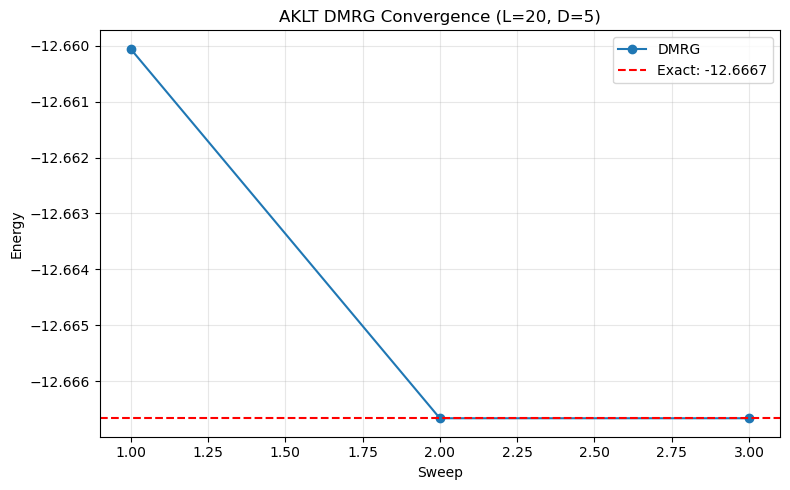

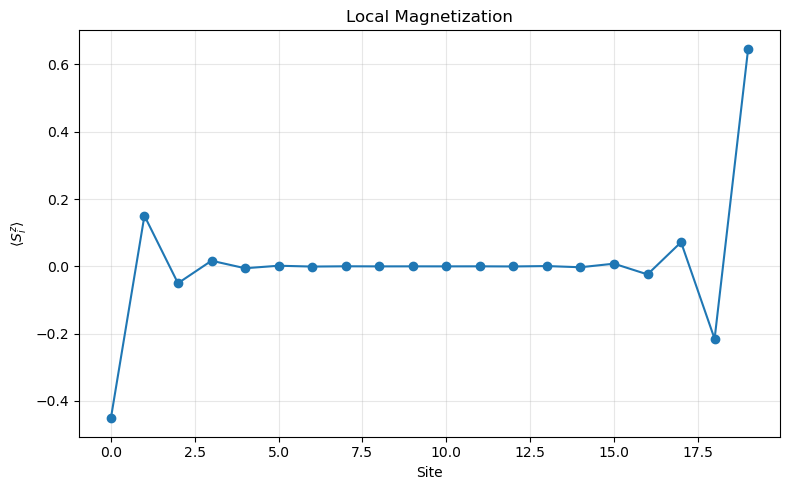

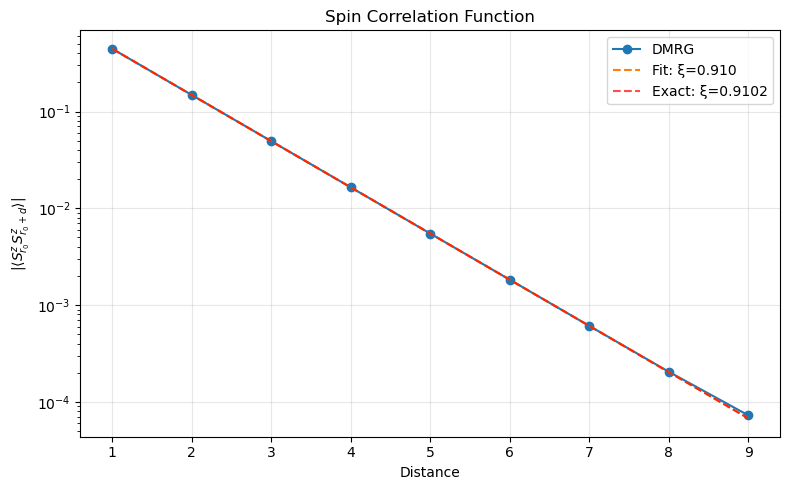

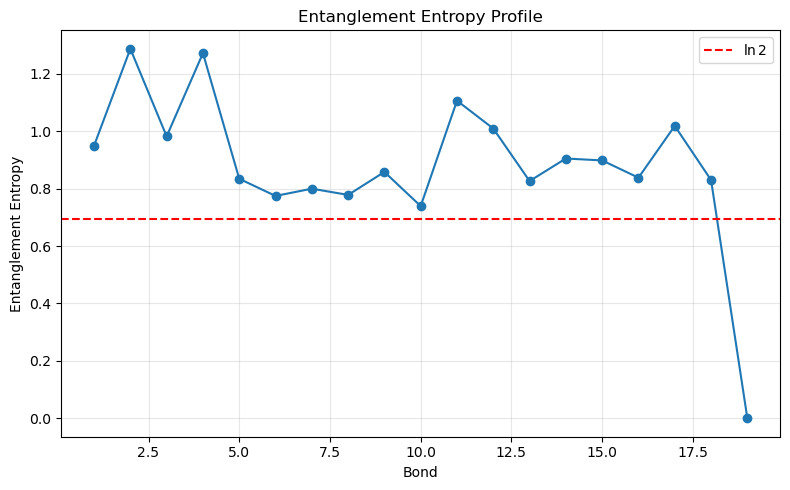

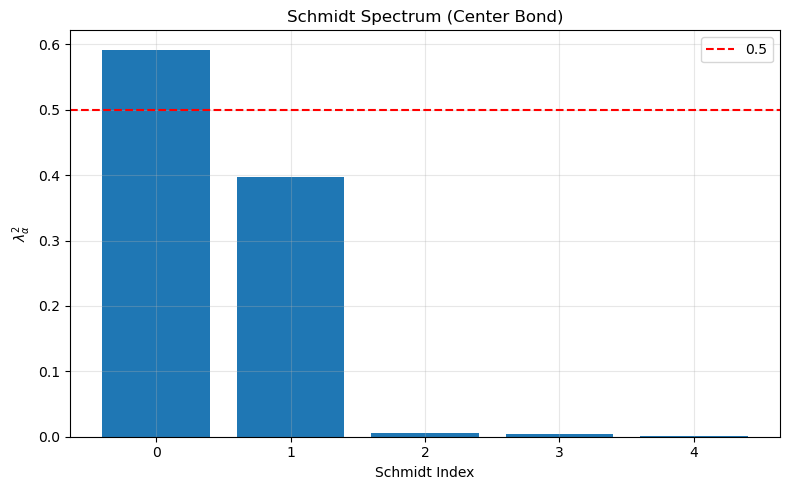

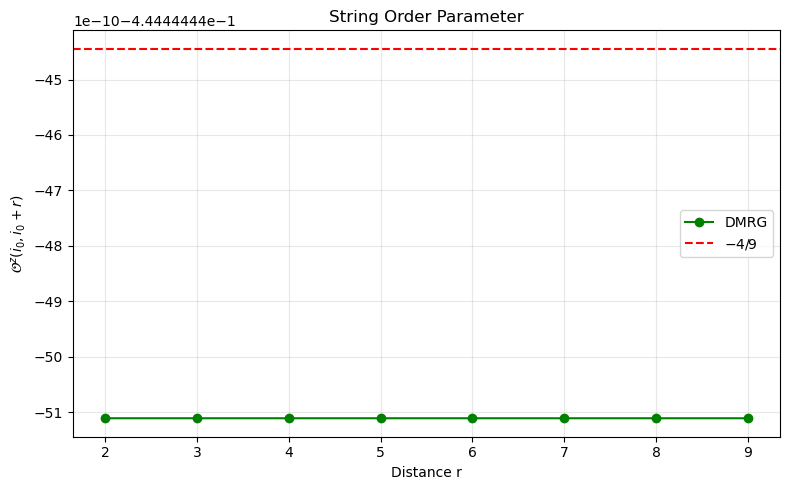

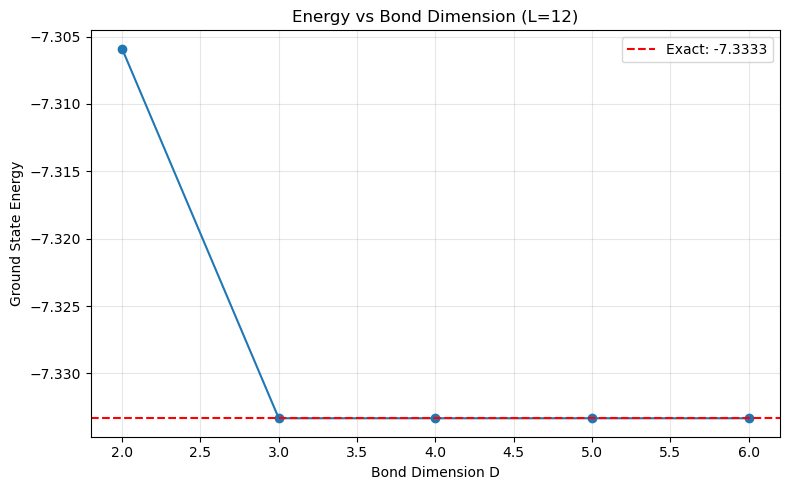

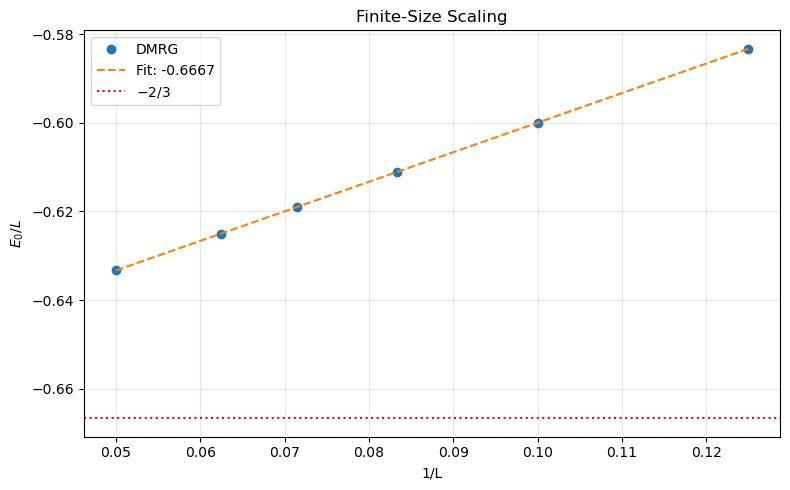

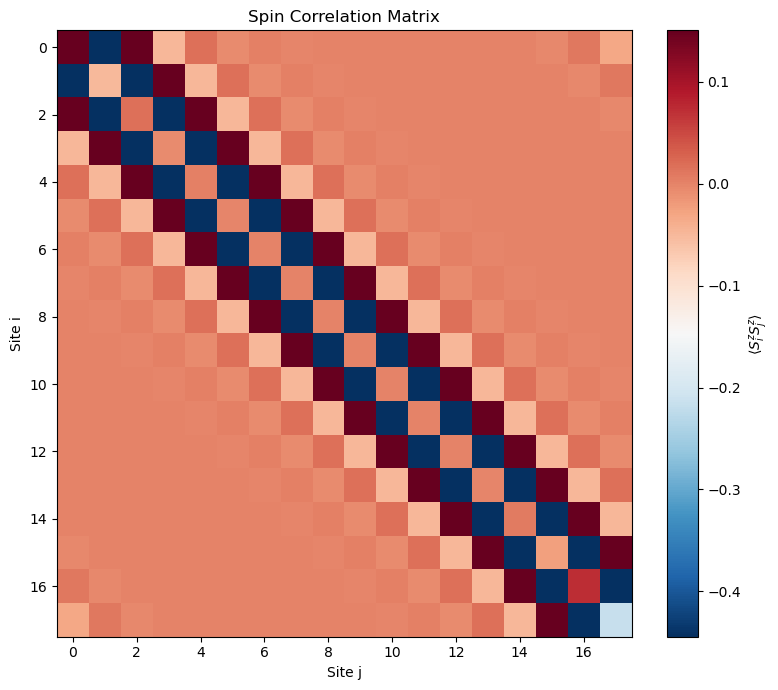

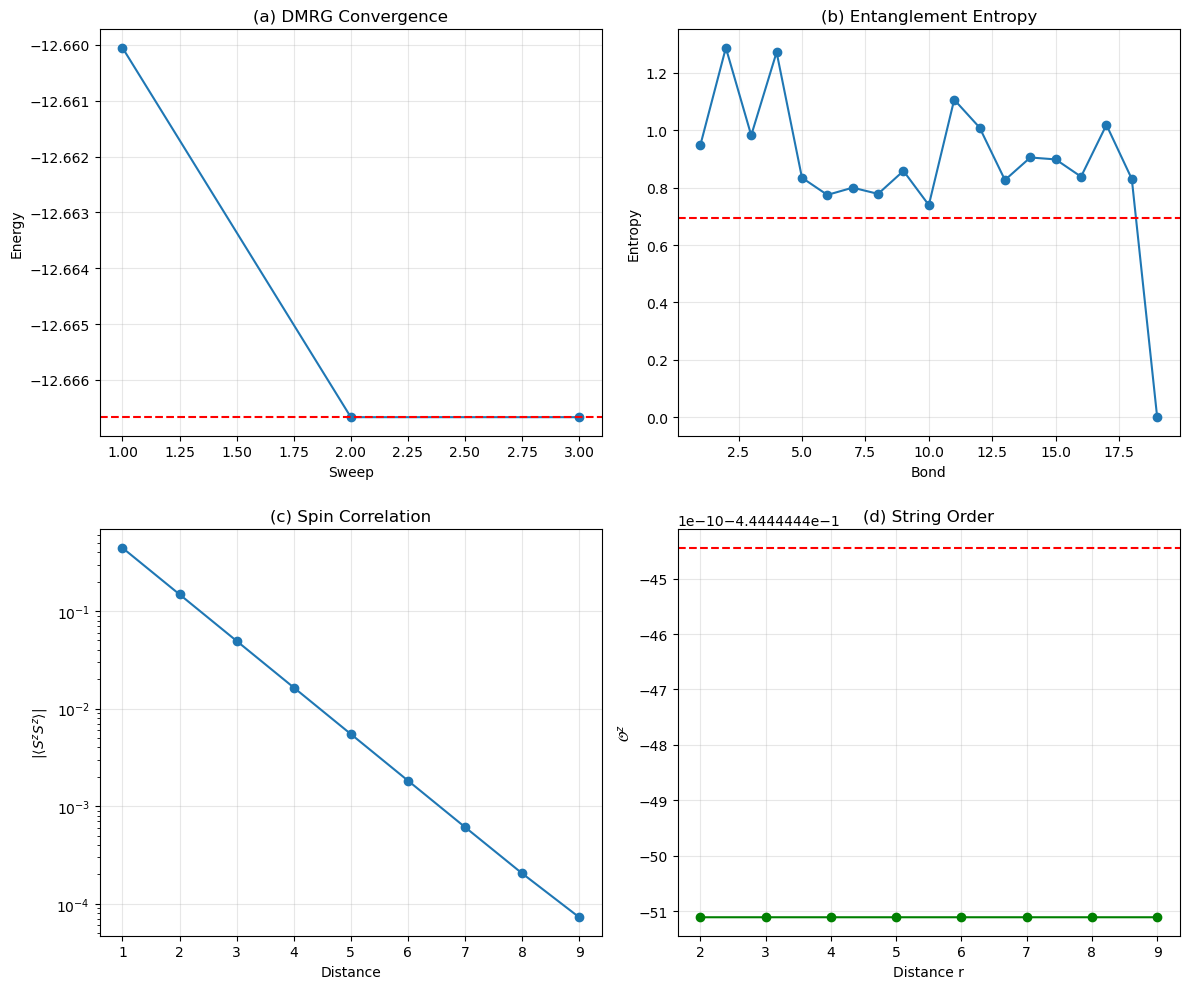

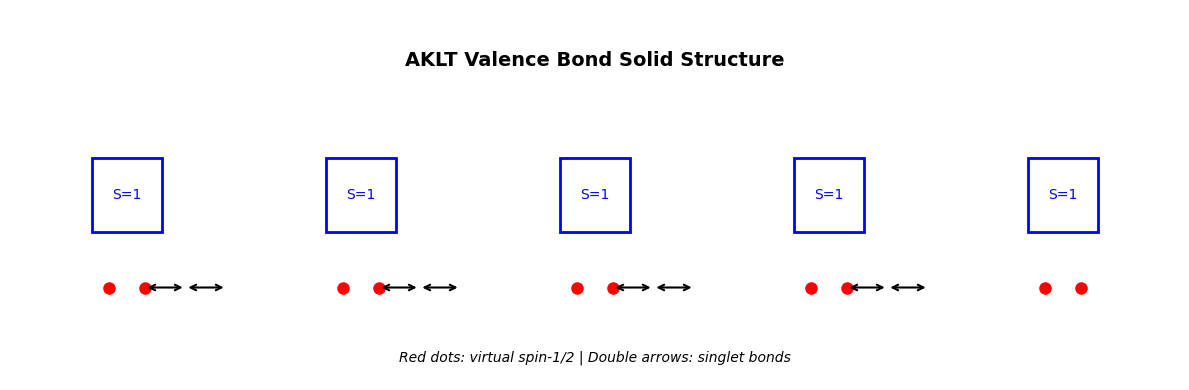


All 11 figures saved to figureAKLT/


In [8]:
import matplotlib.pyplot as plt

# Figure 1: Energy convergence
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(energies)+1), energies, 'o-', label='DMRG')
plt.axhline(E_exact, color='r', linestyle='--', label=f'Exact: {E_exact:.4f}')
plt.xlabel('Sweep')
plt.ylabel('Energy')
plt.title('AKLT DMRG Convergence (L=20, D=5)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/01_energy_convergence.png', dpi=150)
plt.show()

# Figure 2: Local Sz
plt.figure(figsize=(8, 5))
plt.plot(range(L), local_Sz, 'o-')
plt.xlabel('Site')
plt.ylabel(r'$\langle S^z_i \rangle$')
plt.title('Local Magnetization')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/02_local_Sz.png', dpi=150)
plt.show()

# Figure 3: Spin correlation
plt.figure(figsize=(8, 5))
plt.semilogy(corr_distances, corr_values, 'o-', label='DMRG')
plt.semilogy(corr_distances, A_fit*np.exp(-np.array(corr_distances)/xi_fit), 
             '--', label=f'Fit: ξ={xi_fit:.3f}')
xi_exact = 1.0/np.log(3)
plt.semilogy(corr_distances, A_fit*np.exp(-np.array(corr_distances)/xi_exact), 
             'r--', alpha=0.7, label=f'Exact: ξ={xi_exact:.4f}')
plt.xlabel('Distance')
plt.ylabel(r'$|\langle S^z_{r_0} S^z_{r_0+d} \rangle|$')
plt.title('Spin Correlation Function')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/03_spin_correlation.png', dpi=150)
plt.show()

# Figure 4: Entanglement entropy
plt.figure(figsize=(8, 5))
plt.plot(range(1, L), entropies, 'o-')
plt.axhline(np.log(2), color='r', linestyle='--', label=r'$\ln 2$')
plt.xlabel('Bond')
plt.ylabel('Entanglement Entropy')
plt.title('Entanglement Entropy Profile')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/04_entanglement_entropy.png', dpi=150)
plt.show()

# Figure 5: Schmidt spectrum
plt.figure(figsize=(8, 5))
plt.bar(range(len(s2)), s2)
plt.axhline(0.5, color='r', linestyle='--', label='0.5')
plt.xlabel('Schmidt Index')
plt.ylabel(r'$\lambda_\alpha^2$')
plt.title('Schmidt Spectrum (Center Bond)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/05_schmidt_spectrum.png', dpi=150)
plt.show()

# Figure 6: String order
plt.figure(figsize=(8, 5))
plt.plot(string_distances, string_values, 'o-', color='green', label='DMRG')
plt.axhline(-4.0/9.0, color='r', linestyle='--', label=r'$-4/9$')
plt.xlabel('Distance r')
plt.ylabel(r'$\mathcal{O}^z(i_0, i_0+r)$')
plt.title('String Order Parameter')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/06_string_order.png', dpi=150)
plt.show()

# Figure 7: Energy vs D
plt.figure(figsize=(8, 5))
plt.plot(D_values, E_vs_D, 'o-')
plt.axhline(E_exact_small, color='r', linestyle='--', label=f'Exact: {E_exact_small:.4f}')
plt.xlabel('Bond Dimension D')
plt.ylabel('Ground State Energy')
plt.title(f'Energy vs Bond Dimension (L={L_small})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/07_energy_vs_D.png', dpi=150)
plt.show()

# Figure 8: Finite size scaling
plt.figure(figsize=(8, 5))
plt.plot(inv_L, E_per_site, 'o', label='DMRG')
plt.plot(inv_L, np.polyval(fit_coeffs, inv_L), '--', label=f'Fit: {fit_coeffs[1]:.4f}')
plt.axhline(-2.0/3.0, color='r', linestyle=':', label=r'$-2/3$')
plt.xlabel('1/L')
plt.ylabel(r'$E_0/L$')
plt.title('Finite-Size Scaling')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('figureAKLT/08_finite_size_scaling.png', dpi=150)
plt.show()

# Figure 9: Correlation matrix
plt.figure(figsize=(8, 7))
plt.imshow(corr_matrix, cmap='RdBu_r', aspect='auto')
plt.colorbar(label=r'$\langle S^z_i S^z_j \rangle$')
plt.xlabel('Site j')
plt.ylabel('Site i')
plt.title('Spin Correlation Matrix')
plt.tight_layout()
plt.savefig('figureAKLT/09_correlation_matrix.png', dpi=150)
plt.show()

# Figure 10: Summary panel
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0,0].plot(range(1, len(energies)+1), energies, 'o-')
axes[0,0].axhline(E_exact, color='r', linestyle='--')
axes[0,0].set_xlabel('Sweep')
axes[0,0].set_ylabel('Energy')
axes[0,0].set_title('(a) DMRG Convergence')
axes[0,0].grid(True, alpha=0.3)

axes[0,1].plot(range(1, L), entropies, 'o-')
axes[0,1].axhline(np.log(2), color='r', linestyle='--')
axes[0,1].set_xlabel('Bond')
axes[0,1].set_ylabel('Entropy')
axes[0,1].set_title('(b) Entanglement Entropy')
axes[0,1].grid(True, alpha=0.3)

axes[1,0].semilogy(corr_distances, corr_values, 'o-')
axes[1,0].set_xlabel('Distance')
axes[1,0].set_ylabel(r'$|\langle S^z S^z \rangle|$')
axes[1,0].set_title('(c) Spin Correlation')
axes[1,0].grid(True, alpha=0.3)

axes[1,1].plot(string_distances, string_values, 'o-', color='green')
axes[1,1].axhline(-4.0/9.0, color='r', linestyle='--')
axes[1,1].set_xlabel('Distance r')
axes[1,1].set_ylabel(r'$\mathcal{O}^z$')
axes[1,1].set_title('(d) String Order')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figureAKLT/10_summary_panel.png', dpi=150)
plt.show()

# Figure 11: VBS schematic
fig, ax = plt.subplots(figsize=(12, 4))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis('off')

for i in range(5):
    x = 2*i + 1
    ax.add_patch(plt.Rectangle((x-0.3, 0.8), 0.6, 0.4, fill=False, edgecolor='blue', linewidth=2))
    ax.text(x, 1.0, f'S=1', ha='center', va='center', fontsize=10, color='blue')
    
    ax.plot(x-0.15, 0.5, 'ro', markersize=8)
    ax.plot(x+0.15, 0.5, 'ro', markersize=8)
    
    if i < 4:
        ax.annotate('', xy=(x+0.15+0.35, 0.5), xytext=(x+0.15, 0.5),
                   arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))
        ax.annotate('', xy=(x+0.85, 0.5), xytext=(x+0.15+0.35, 0.5),
                   arrowprops=dict(arrowstyle='<->', color='black', lw=1.5))

ax.text(5, 1.7, 'AKLT Valence Bond Solid Structure', ha='center', fontsize=14, weight='bold')
ax.text(5, 0.1, 'Red dots: virtual spin-1/2 | Double arrows: singlet bonds', 
        ha='center', fontsize=10, style='italic')

plt.tight_layout()
plt.savefig('figureAKLT/11_vbs_schematic.png', dpi=150)
plt.show()

print("\n" + "="*60)
print("All 11 figures saved to figureAKLT/")
print("="*60)